# Reusable PennyLane QAOA Portfolio Optimization Notebook

This notebook turns the original hardcoded demo into a reusable **experiment notebook** for binary mean-variance portfolio optimization with **QAOA in PennyLane**.

We follow the report math throughout:

1. binary portfolio problem
2. penalized QUBO
3. Ising / cost Hamiltonian via `x_i = (1 - Z_i) / 2`
4. QAOA optimization and sampling
5. lightweight hyperparameter studies

The shared math, plotting, and CSV utilities now live in `portfolio_qaoa_core.py`, while the PennyLane execution path lives in `portfolio_qaoa_pennylane.py`. This notebook stays focused on configuration, interpretation, and plots, and the demo pipeline below still defaults to a single seeded **generated** example.


## 1. Setup / imports

The notebook imports shared helpers from the project-level core module and PennyLane-specific execution helpers from the local PennyLane module so the cells stay short and report-friendly.


In [16]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

CURRENT_DIR = Path.cwd().resolve()
if (CURRENT_DIR / "portfolio_qaoa_core.py").exists():
    PROJECT_ROOT = CURRENT_DIR
elif (CURRENT_DIR.parent / "portfolio_qaoa_core.py").exists():
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    raise FileNotFoundError("Could not locate portfolio_qaoa_core.py from the current working directory.")

NOTEBOOK_DIR = PROJECT_ROOT / "pennylane"
for import_path in (PROJECT_ROOT, NOTEBOOK_DIR):
    if str(import_path) not in sys.path:
        sys.path.insert(0, str(import_path))

from portfolio_qaoa_core import (
    bruteforce_portfolio_baseline,
    compare_analytical_and_numerical_ising,
    enumerate_bitstrings,
    evaluate_qubo_cost,
    expected_return,
    generate_random_portfolio_instance,
    get_default_worked_example,
    ising_energy_from_bitstring,
    load_search_results,
    penalized_cost,
    plot_asset_count_study,
    plot_bitstring_distribution,
    plot_depth_study,
    plot_feasible_rate_vs_lambda,
    plot_optimization_convergence,
    plot_noisy_feasible_sample_rate,
    plot_noisy_optimum_probability,
    plot_noisy_sweep_combined,
    plot_score_weighted_hyperparam_distributions,
    plot_topk_hyperparam_frequencies,
    plot_risk_aversion_study,
    plot_risk_return_scatter,
    postprocess_saved_search_results,
    portfolio_cost,
    portfolio_qubo_coeffs,
    portfolio_variance,
    qubo_to_ising,
    print_noisy_sweep_summary_table,
    save_noisy_sweep_results_csv,
)

from portfolio_qaoa_pennylane import (
    build_cost_hamiltonian,
    make_x_mixer,
    run_noisy_cartesian_sweep,
    run_qaoa_experiment,
    sweep_noisy_hyperparam,
    sweep_parameter,
)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


## 2. Portfolio instance generation or manual example

We keep both:

- a small hand-written worked example for debugging and report alignment
- a seeded generated example for experiment-style demos

By default, the notebook uses the generated example as the active demo instance. Switch the `active_example_name` line below to `"worked"` if you want the manual example instead.


In [2]:
worked_example = get_default_worked_example()
generated_mu, generated_Sigma = generate_random_portfolio_instance(n_assets=5, seed=1)
generated_example = {
    "name": "Generated example",
    "mu": generated_mu,
    "Sigma": generated_Sigma,
    "q": 1.0,
    "B": 3,
    "lam": 1.0,
    "seed": 123,
}

active_example_name = "generated"  # change to "worked" to use the manual 3-asset example
active_example = generated_example if active_example_name == "generated" else worked_example

print("Worked example:")
print("mu =", worked_example["mu"])
print("Sigma =\n", worked_example["Sigma"])
print("q =", worked_example["q"], "| B =", worked_example["B"], "| lambda =", worked_example["lam"])

print("\nGenerated example:")
print("mu =", np.round(generated_example["mu"], 4))
print("Sigma =\n", np.round(generated_example["Sigma"], 4))
print("q =", generated_example["q"], "| B =", generated_example["B"], "| lambda =", generated_example["lam"])

print("\nActive example:", active_example.get("name", active_example_name))
print("Number of assets =", len(active_example["mu"]))


Worked example:
mu = [0.1  0.2  0.15]
Sigma =
 [[0.05 0.01 0.02]
 [0.01 0.06 0.01]
 [0.02 0.01 0.04]]
q = 1.0 | B = 2 | lambda = 1.0

Generated example:
mu = [0.1524 0.2401 0.0788 0.2397 0.1124]
Sigma =
 [[ 0.0539 -0.0091 -0.0005  0.0072  0.0008]
 [-0.0091  0.0862 -0.0023 -0.0162 -0.0008]
 [-0.0005 -0.0023  0.0527  0.0029 -0.0063]
 [ 0.0072 -0.0162  0.0029  0.064  -0.0015]
 [ 0.0008 -0.0008 -0.0063 -0.0015  0.0222]]
q = 1.0 | B = 3 | lambda = 1.0

Active example: Generated example
Number of assets = 5


## 3. Classical objective definitions

The binary mean-variance objective is

$$
q x^T \Sigma x - \mu^T x
$$

with the quadratic penalty

$$
\lambda \left(\sum_i x_i - B\right)^2.
$$

The module exposes reusable classical helpers so every downstream routine can call them directly.


In [3]:
mu = active_example["mu"]
Sigma = active_example["Sigma"]
q = active_example["q"]
B = active_example["B"]
lam = active_example["lam"]
preview_x = tuple(1 if i < B else 0 for i in range(len(mu)))

print("Preview portfolio:", preview_x)
print("Expected return =", expected_return(preview_x, mu))
print("Variance =", portfolio_variance(preview_x, Sigma))
print("Raw objective =", portfolio_cost(preview_x, mu, Sigma, q))
print("Penalized objective =", penalized_cost(preview_x, mu, Sigma, q, B, lam))


Preview portfolio: (1, 1, 1, 0, 0)
Expected return = 0.4712889867491652
Variance = 0.16903735509456183
Raw objective = -0.30225163165460334
Penalized objective = -0.30225163165460334


## 4. Analytical QUBO derivation functions

Starting from

$$
f(x) = q x^T \Sigma x - \mu^T x + \lambda \left(\sum_i x_i - B\right)^2,
$$

we write the penalized objective in QUBO form

$$
f(x) = \text{const} + \sum_i a_i x_i + \sum_{i<j} b_{ij} x_i x_j.
$$

For symmetric `Sigma`, the notebook uses the analytical coefficients

- `const = lambda * B^2`
- `a_i = q * Sigma_ii - mu_i + lambda * (1 - 2B)`
- `b_ij = 2 * q * Sigma_ij + 2 * lambda`


In [4]:
qubo_const, qubo_linear, qubo_quad = portfolio_qubo_coeffs(mu, Sigma, q, B, lam)

print("QUBO constant:", qubo_const)
print("QUBO linear coefficients:", np.round(qubo_linear, 6))
print("QUBO quadratic coefficients:")
for key, value in qubo_quad.items():
    print(f"  {key}: {value:.6f}")


QUBO constant: 9.0
QUBO linear coefficients: [-5.098498 -5.153877 -5.026096 -5.175762 -5.090162]
QUBO quadratic coefficients:
  (0, 1): 1.981785
  (0, 2): 1.998935
  (0, 3): 2.014442
  (0, 4): 2.001610
  (1, 2): 1.995499
  (1, 3): 1.967645
  (1, 4): 1.998300
  (2, 3): 2.005845
  (2, 4): 1.987339
  (3, 4): 1.997045


## 5. Analytical Ising / Hamiltonian derivation functions

Using the standard substitution

$$
x_i = \frac{1 - Z_i}{2},
$$

we convert the QUBO into an Ising Hamiltonian

$$
H_C = c_0 I + \sum_i c_i Z_i + \sum_{i<j} c_{ij} Z_i Z_j.
$$

This analytical conversion is the **main path** used by the experiment runner.


In [5]:
ising_c0, ising_z, ising_zz = qubo_to_ising(qubo_const, qubo_linear, qubo_quad)
cost_h = build_cost_hamiltonian(ising_c0, ising_z, ising_zz)

print("Ising constant c0:", round(ising_c0, 6))
print("Single-qubit Z coefficients:", np.round(ising_z, 6))
print("Two-qubit ZZ coefficients:")
for key, value in ising_zz.items():
    print(f"  {key}: {value:.6f}")

print("\nPennyLane cost Hamiltonian:")
print(cost_h)


Ising constant c0: 1.214914
Single-qubit Z coefficients: [0.550056 0.591131 0.516143 0.591637 0.549007]
Two-qubit ZZ coefficients:
  (0, 1): 0.495446
  (0, 2): 0.499734
  (0, 3): 0.503611
  (0, 4): 0.500403
  (1, 2): 0.498875
  (1, 3): 0.491911
  (1, 4): 0.499575
  (2, 3): 0.501461
  (2, 4): 0.496835
  (3, 4): 0.499261

PennyLane cost Hamiltonian:
1.2149141583187657 * I(0) + 0.5500560235712023 * Z(0) + 0.5911310012676547 * Z(1) + 0.5161433189895344 * Z(2) + 0.5916368360571811 * Z(3) + 0.5490071593906731 * Z(4) + 0.49544619239347293 * (Z(0) @ Z(1)) + 0.49973379519907185 * (Z(0) @ Z(2)) + 0.5036105852996546 * (Z(0) @ Z(3)) + 0.5004025080477207 * (Z(0) @ Z(4)) + 0.4988747875978521 * (Z(1) @ Z(2)) + 0.4919111947784622 * (Z(1) @ Z(3)) + 0.4995750898423337 * (Z(1) @ Z(4)) + 0.501461325855822 * (Z(2) @ Z(3)) + 0.4968347681749166 * (Z(2) @ Z(4)) + 0.4992612552156818 * (Z(3) @ Z(4))


### Optional validation

For the small worked example, we can compare the analytical Ising coefficients against the old numerical reconstruction and also verify basis-state energies directly.


In [6]:
qubo_errors = []
ising_errors = []
for bits in enumerate_bitstrings(len(mu)):
    direct_cost = penalized_cost(bits, mu, Sigma, q, B, lam)
    qubo_cost = evaluate_qubo_cost(bits, qubo_const, qubo_linear, qubo_quad)
    ising_cost = ising_energy_from_bitstring(bits, ising_c0, ising_z, ising_zz)
    qubo_errors.append(abs(direct_cost - qubo_cost))
    ising_errors.append(abs(direct_cost - ising_cost))

numerical_check = compare_analytical_and_numerical_ising(mu, Sigma, q, B, lam)

print("Max |direct - analytical QUBO|:", max(qubo_errors))
print("Max |direct - analytical Ising|:", max(ising_errors))
print("Max |analytical - numerical coefficients|:")
print(numerical_check["max_abs_diff"])


Max |direct - analytical QUBO|: 2.886579864025407e-15
Max |direct - analytical Ising|: 1.6653345369377348e-15
Max |analytical - numerical coefficients|:
{'c0': 2.220446049250313e-16, 'z': 1.1102230246251565e-15, 'zz': 4.996003610813204e-16}


## 6. Classical brute-force baseline

For small toy instances, brute force gives the exact constrained optimum and a clean reference point for the QAOA experiments.


In [7]:
classical_active = bruteforce_portfolio_baseline(mu, Sigma, q, B, lam)

print("Best feasible portfolio:")
print(classical_active["best_feasible"])

print("\nBest penalized portfolio:")
print(classical_active["best_penalized"])

print("\nTop feasible portfolios by objective:")
for record in classical_active["feasible_records"][:5]:
    print(record)


Best feasible portfolio:
{'bitstring': (1, 1, 0, 1, 0), 'bitstring_str': '11010', 'selected_assets': 3, 'is_feasible': True, 'expected_return': 0.6321869536326872, 'variance': 0.16792170832364517, 'stdev': 0.4097825134429789, 'raw_objective': -0.464265245309042, 'penalty': 0.0, 'penalized_objective': -0.464265245309042}

Best penalized portfolio:
{'bitstring': (1, 1, 0, 1, 0), 'bitstring_str': '11010', 'selected_assets': 3, 'is_feasible': True, 'expected_return': 0.6321869536326872, 'variance': 0.16792170832364517, 'stdev': 0.4097825134429789, 'raw_objective': -0.464265245309042, 'penalty': 0.0, 'penalized_objective': -0.464265245309042}

Top feasible portfolios by objective:
{'bitstring': (1, 1, 0, 1, 0), 'bitstring_str': '11010', 'selected_assets': 3, 'is_feasible': True, 'expected_return': 0.6321869536326872, 'variance': 0.16792170832364517, 'stdev': 0.4097825134429789, 'raw_objective': -0.464265245309042, 'penalty': 0.0, 'penalized_objective': -0.464265245309042}
{'bitstring': (0, 

## 7. Finance visualization helpers

For feasible portfolios we track expected return, variance, standard deviation, and objective value. The same records also support a simple efficient-frontier overlay for the active example.


In [8]:
print("Efficient frontier records for the active example:")
for record in classical_active["efficient_frontier_records"]:
    print(record)


Efficient frontier records for the active example:
{'bitstring': (1, 0, 1, 0, 1), 'bitstring_str': '10101', 'selected_assets': 3, 'is_feasible': True, 'expected_return': 0.3435625378860752, 'variance': 0.11669106157362094, 'stdev': 0.34160073415263753, 'raw_objective': -0.22687147631245427, 'penalty': 0.0, 'penalized_objective': -0.22687147631245427}
{'bitstring': (0, 0, 1, 1, 1), 'bitstring_str': '00111', 'selected_assets': 3, 'is_feasible': True, 'expected_return': 0.4309281023734726, 'variance': 0.12913755196850496, 'stdev': 0.35935713707745526, 'raw_objective': -0.30179055040496766, 'penalty': 0.0, 'penalized_objective': -0.30179055040496766}
{'bitstring': (0, 1, 0, 1, 1), 'bitstring_str': '01011', 'selected_assets': 3, 'is_feasible': True, 'expected_return': 0.5921889190947329, 'variance': 0.13537859092483612, 'stdev': 0.36793829771421743, 'raw_objective': -0.4568103281698968, 'penalty': 0.0, 'penalized_objective': -0.4568103281698968}
{'bitstring': (1, 1, 0, 1, 0), 'bitstring_str

## 8. PennyLane QAOA implementation

We use the standard **X mixer** and separate devices for expectation-value optimization and finite-shot sampling. The helper functions also support the `p = 0` baseline, where the circuit is just a layer of Hadamards.


In [9]:
mixer_preview = make_x_mixer(len(mu))
print("Default X mixer:")
print(mixer_preview)
print("\np = 0 is handled automatically by run_qaoa_experiment(...).")


Default X mixer:
1 * X(0) + 1 * X(1) + 1 * X(2) + 1 * X(3) + 1 * X(4)

p = 0 is handled automatically by run_qaoa_experiment(...).


## 9. Experiment runner

The main reusable entry point is `run_qaoa_experiment(...)`, which packages the classical baseline, analytical coefficients, QAOA optimization, and shot-based sampling into one structured result dictionary.


In [10]:
demo_config = {
    "mu": active_example["mu"],
    "Sigma": active_example["Sigma"],
    "q": active_example["q"],
    "B": active_example["B"],
    "lam": active_example["lam"],
    "p": 30,
    "shots": 1000,
    "n_steps": 100,
    "stepsize": 0.1,
    "seed": 7,
    "optimizer_name": "adam",
}

print("Active demo config:")
print(demo_config)


Active demo config:
{'mu': array([0.15236432, 0.24009274, 0.07883192, 0.23972989, 0.11236629]), 'Sigma': array([[ 0.05386612, -0.00910762, -0.00053241,  0.00722117,  0.00080502],
       [-0.00910762,  0.08621621, -0.00225042, -0.01617761, -0.00084982],
       [-0.00053241, -0.00225042,  0.05273593,  0.00292265, -0.00633046],
       [ 0.00722117, -0.01617761,  0.00292265,  0.0639675 , -0.00147749],
       [ 0.00080502, -0.00084982, -0.00633046, -0.00147749,  0.02220473]]), 'q': 1.0, 'B': 3, 'lam': 1.0, 'p': 30, 'shots': 1000, 'n_steps': 100, 'stepsize': 0.1, 'seed': 7, 'optimizer_name': 'adam'}


## 10. Plotting helpers

The module provides reusable plotting functions for convergence, sampled bitstrings, finance visuals, and lightweight study plots.


In [11]:
plotting_helpers = [
    "plot_optimization_convergence",
    "plot_bitstring_distribution",
    "plot_feasible_rate_vs_lambda",
    "plot_depth_study",
    "plot_risk_aversion_study",
    "plot_asset_count_study",
    "plot_risk_return_scatter",
    "plot_noisy_optimum_probability",
    "plot_noisy_feasible_sample_rate",
    "plot_noisy_sweep_combined",
    "plot_topk_hyperparam_frequencies",
    "plot_score_weighted_hyperparam_distributions",
]

print("Available plotting helpers:")
for name in plotting_helpers:
    print(" -", name)


Available plotting helpers:
 - plot_optimization_convergence
 - plot_bitstring_distribution
 - plot_feasible_rate_vs_lambda
 - plot_depth_study
 - plot_risk_aversion_study
 - plot_asset_count_study
 - plot_risk_return_scatter
 - plot_noisy_optimum_probability
 - plot_noisy_feasible_sample_rate
 - plot_noisy_sweep_combined


## 11. Default demo

This section is the polished top-to-bottom demo for the currently active example: solve one small instance, compare against the classical optimum, inspect optimization convergence, view the sampled bitstrings, and look at the finance scatter plot.


In [25]:
demo_result = run_qaoa_experiment(
    mu=demo_config["mu"],
    Sigma=demo_config["Sigma"],
    q=demo_config["q"],
    B=demo_config["B"],
    lam=demo_config["lam"],
    p=demo_config["p"],
    shots=demo_config["shots"],
    n_steps=demo_config["n_steps"],
    stepsize=demo_config["stepsize"],
    seed=demo_config["seed"],
    optimizer_name=demo_config["optimizer_name"],
)

print("Classical best feasible portfolio:")
print(demo_result["classical"]["best_feasible"])

print("\nClassical best penalized portfolio:")
print(demo_result["classical"]["best_penalized"])

print("\nQAOA summary:")
print("Final expected cost =", demo_result["optimization"]["final_expected_cost"])
print("Best sampled portfolio =", demo_result["samples"]["best_sampled"])
print("Best feasible sampled portfolio =", demo_result["samples"]["best_feasible_sampled"])
print("Feasible sample rate =", demo_result["samples"]["feasible_sample_rate"])
print("Probability of the classical optimum =", demo_result["samples"]["classical_best_feasible_prob"])
print("Runtime (seconds) =", round(demo_result["runtime_sec"], 3))

print("\nTop sampled portfolios:")
for record in demo_result["samples"]["top_sampled"]:
    print(record)


Classical best feasible portfolio:
{'bitstring': (1, 1, 0, 1, 0), 'bitstring_str': '11010', 'selected_assets': 3, 'is_feasible': True, 'expected_return': 0.6321869536326872, 'variance': 0.16792170832364517, 'stdev': 0.4097825134429789, 'raw_objective': -0.464265245309042, 'penalty': 0.0, 'penalized_objective': -0.464265245309042}

Classical best penalized portfolio:
{'bitstring': (1, 1, 0, 1, 0), 'bitstring_str': '11010', 'selected_assets': 3, 'is_feasible': True, 'expected_return': 0.6321869536326872, 'variance': 0.16792170832364517, 'stdev': 0.4097825134429789, 'raw_objective': -0.464265245309042, 'penalty': 0.0, 'penalized_objective': -0.464265245309042}

QAOA summary:
Final expected cost = -0.3826689849432289
Best sampled portfolio = {'bitstring': (1, 1, 0, 1, 0), 'bitstring_str': '11010', 'selected_assets': 3, 'is_feasible': True, 'expected_return': 0.6321869536326872, 'variance': 0.16792170832364517, 'stdev': 0.4097825134429789, 'raw_objective': -0.464265245309042, 'penalty': 0.0

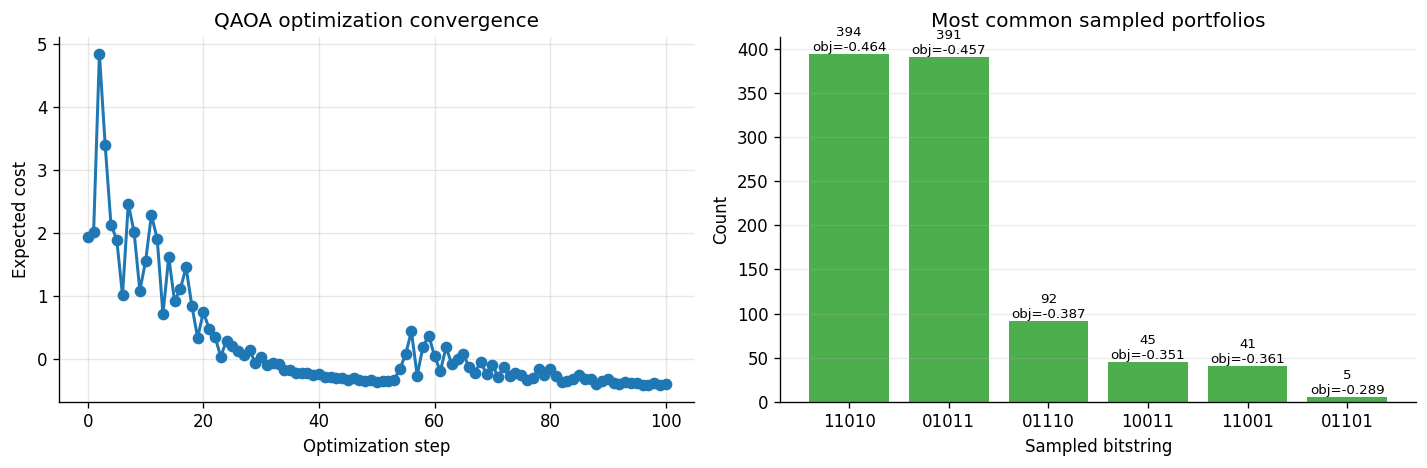

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_optimization_convergence(demo_result, ax=axes[0])
plot_bitstring_distribution(demo_result, top_k=6, ax=axes[1])
plt.tight_layout()
plt.show()


<Figure size 720x480 with 0 Axes>

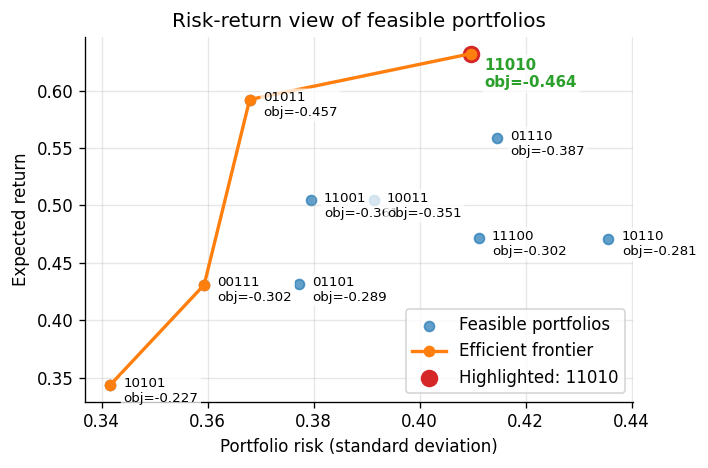

In [27]:
plt.figure(figsize=(6, 4))
plot_risk_return_scatter(demo_result["classical"], show_frontier=True)
plt.tight_layout()
plt.show()


## 12. Hyperparameter sweep helpers

Once the main demo is complete, the generic `sweep_parameter(...)` helper reruns the full experiment for one changed parameter at a time and stores both the full runs and flat summary records.


In [28]:
depth_sweep_config = {
    "mu": active_example["mu"],
    "Sigma": active_example["Sigma"],
    "q": active_example["q"],
    "B": active_example["B"],
    "lam": active_example["lam"],
    "p": 2,
    "shots": 400,
    "n_steps": 30,
    "stepsize": 0.1,
    "seed": 7,
    "optimizer_name": "adam",
}

lambda_sweep_config = dict(depth_sweep_config)
q_sweep_config = dict(depth_sweep_config)
asset_count_sweep_config = {
    "n_assets": 3,
    "q": 1.0,
    "B": 2,
    "budget_rule": "ceil_half",
    "lam": 1.0,
    "p": 10,
    "shots": 250,
    "n_steps": 20,
    "stepsize": 0.1,
    "seed": 7,
    "instance_seed": 100,
    "optimizer_name": "adam",
}

print("Sweep configs ready for depth, lambda, q, and asset-count studies.")
print("Asset-count sweep budget rule: B = ceil(n_assets / 2)")


Sweep configs ready for depth, lambda, q, and asset-count studies.
Asset-count sweep budget rule: B = ceil(n_assets / 2)


## 13. Hyperparameter exploration examples

These are intentionally lightweight examples so the notebook still runs comfortably top-to-bottom after the main demo finishes.


Depth sweep summary records:
{'param_name': 'p', 'param_value': 0, 'n_assets': 5, 'q': 1.0, 'B': 3, 'lam': 1.0, 'p': 0, 'final_expected_cost': 1.2149141583187648, 'best_classical_feasible_objective': -0.464265245309042, 'best_sampled_objective': -0.464265245309042, 'best_sampled_bitstring': '11010', 'best_feasible_sampled_objective': -0.464265245309042, 'best_feasible_sampled_bitstring': '11010', 'feasible_sample_rate': 0.285, 'classical_optimum_prob': 0.035, 'runtime_sec': 0.008479000010993332}
{'param_name': 'p', 'param_value': 1, 'n_assets': 5, 'q': 1.0, 'B': 3, 'lam': 1.0, 'p': 1, 'final_expected_cost': 0.2361915731405398, 'best_classical_feasible_objective': -0.464265245309042, 'best_sampled_objective': -0.464265245309042, 'best_sampled_bitstring': '11010', 'best_feasible_sampled_objective': -0.464265245309042, 'best_feasible_sampled_bitstring': '11010', 'feasible_sample_rate': 0.575, 'classical_optimum_prob': 0.075, 'runtime_sec': 0.6574822000111453}
{'param_name': 'p', 'param_va

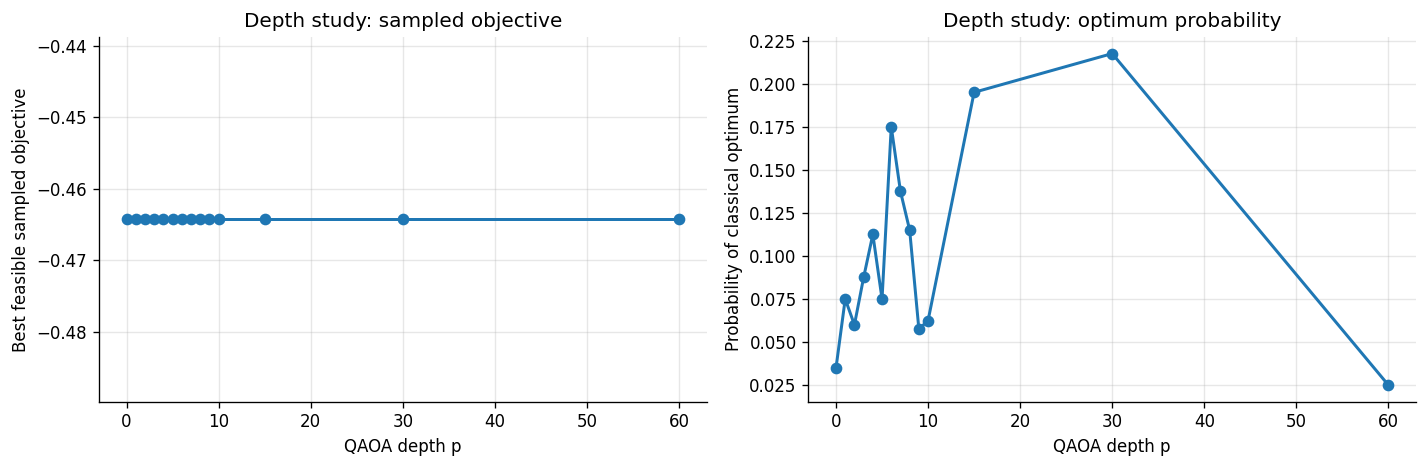

<Figure size 720x480 with 0 Axes>

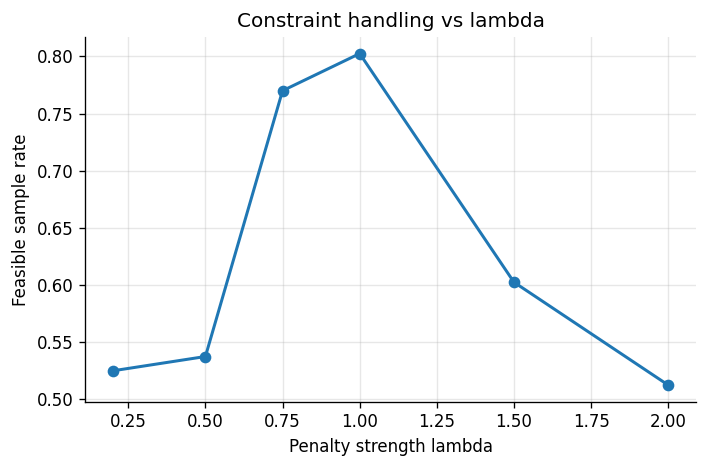

In [51]:
depth_sweep = sweep_parameter(depth_sweep_config, param_name="p", values=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 30, 60], seed=7)
lambda_sweep = sweep_parameter(lambda_sweep_config, param_name="lam", values=[0.2, 0.5, 0.75, 1.0,1.5, 2.0], seed=7)

print("Depth sweep summary records:")
for record in depth_sweep["records"]:
    print(record)

print("\nLambda sweep summary records:")
for record in lambda_sweep["records"]:
    print(record)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_depth_study(depth_sweep, axes=axes)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plot_feasible_rate_vs_lambda(lambda_sweep)
plt.tight_layout()
plt.show()


Risk-aversion sweep summary records:
{'param_name': 'q', 'param_value': 0.5, 'n_assets': 5, 'q': 0.5, 'B': 3, 'lam': 1.0, 'p': 2, 'final_expected_cost': -0.04140451943341883, 'best_classical_feasible_objective': -0.5482260994708645, 'best_sampled_objective': -0.5482260994708645, 'best_sampled_bitstring': '11010', 'best_feasible_sampled_objective': -0.5482260994708645, 'best_feasible_sampled_bitstring': '11010', 'feasible_sample_rate': 0.765, 'classical_optimum_prob': 0.0525, 'runtime_sec': 1.030689400009578}
{'param_name': 'q', 'param_value': 1.0, 'n_assets': 5, 'q': 1.0, 'B': 3, 'lam': 1.0, 'p': 2, 'final_expected_cost': -0.026198065966610076, 'best_classical_feasible_objective': -0.464265245309042, 'best_sampled_objective': -0.464265245309042, 'best_sampled_bitstring': '11010', 'best_feasible_sampled_objective': -0.464265245309042, 'best_feasible_sampled_bitstring': '11010', 'feasible_sample_rate': 0.8025, 'classical_optimum_prob': 0.06, 'runtime_sec': 1.0104968000086956}
{'param_nam

<Figure size 840x480 with 0 Axes>

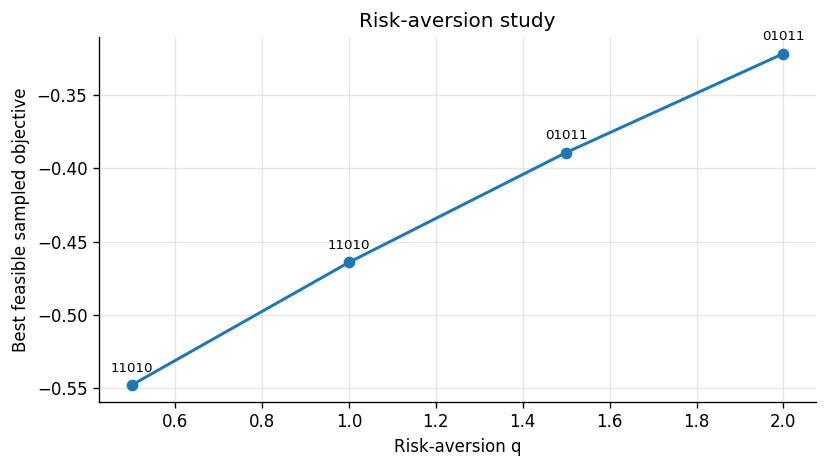

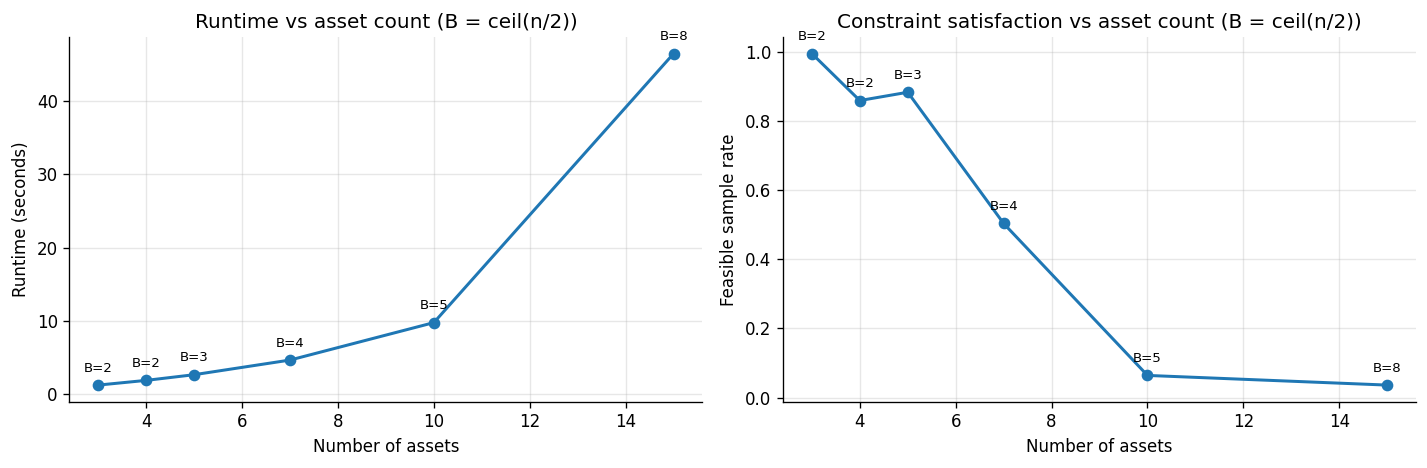

In [30]:
q_sweep = sweep_parameter(q_sweep_config, param_name="q", values=[0.5, 1.0, 1.5, 2.0], seed=7)
asset_count_sweep = sweep_parameter(asset_count_sweep_config, param_name="n_assets", values=[3, 4, 5, 7, 10, 15], seed=7)

print("Risk-aversion sweep summary records:")
for record in q_sweep["records"]:
    print(record)

print("\nAsset-count sweep summary records:")
for record in asset_count_sweep["records"]:
    print(record)

plt.figure(figsize=(7, 4))
plot_risk_aversion_study(q_sweep)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_asset_count_study(asset_count_sweep, axes=axes)
plt.tight_layout()
plt.show()


### Optimum probability vs asset count

This final plot shows how often the classical best portfolio is sampled as the number of assets grows, with the dynamic budget rule `B = ceil(n/2)` labeled directly on the graph.


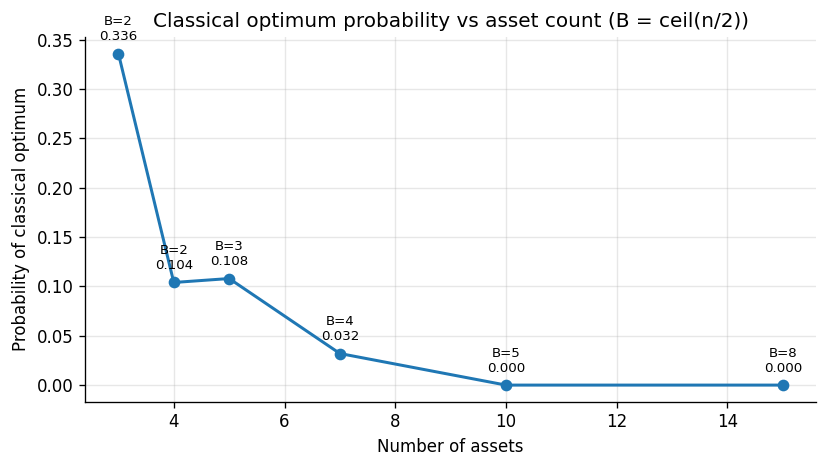

In [31]:
asset_count_records = sorted(asset_count_sweep["records"], key=lambda record: record["param_value"])
asset_counts = [record["param_value"] for record in asset_count_records]
asset_budgets = [record["B"] for record in asset_count_records]
optimum_probs = [record["classical_optimum_prob"] for record in asset_count_records]

plt.figure(figsize=(7, 4))
plt.plot(asset_counts, optimum_probs, marker="o", linewidth=1.8)
for asset_count, budget, optimum_prob in zip(asset_counts, asset_budgets, optimum_probs):
    plt.annotate(f"B={budget}\n{optimum_prob:.3f}", (asset_count, optimum_prob), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8)
plt.xlabel("Number of assets")
plt.ylabel("Probability of classical optimum")
plt.title("Classical optimum probability vs asset count (B = ceil(n/2))")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 14. Noisy simulation study

This appended section keeps the same `default.mixed` noisy backend, but now compares noisy QAOA settings by averaging over **three different random portfolio instances** for each asset count. Depth is shown first, and the full Cartesian hyperparameter comparisons are available behind a flag.


In [5]:
noisy_results_dir = NOTEBOOK_DIR / "noisy_results"

noisy_budget_options = {3: [1, 2], 4: [2, 3]}
valid_noisy_budget_options = {}

for n_assets, budgets in noisy_budget_options.items():
    valid_budgets = []
    for budget in budgets:
        if 0 <= int(budget) <= int(n_assets):
            valid_budgets.append(int(budget))
        else:
            print(f"Skipping invalid noisy budget B={budget} for n_assets={n_assets}.")
    valid_noisy_budget_options[n_assets] = valid_budgets

noisy_shared_defaults = {
    "q": 1.0,
    "lam": 1.0,
    "shots": 300,
    "stepsize": 0.1,
    "n_steps": 20,
    "optimizer_name": "adam",
    "noise_mode": "layer_depolarizing",
    "noise_strength": 0.01,
}

noisy_depth_values = [0, 1, 2, 3, 4,5, 10, 15]
noisy_depth_instance_seeds = {3: [103, 203, 303], 4: [104, 204, 304]}

print("Validated noisy budget options:", valid_noisy_budget_options)
print("Depth values:", noisy_depth_values)
print("Depth-study portfolio seeds:", noisy_depth_instance_seeds)
print("Noisy result CSV directory:", noisy_results_dir)


Validated noisy budget options: {3: [1, 2], 4: [2, 3]}
Depth values: [0, 1, 2, 3, 4, 5, 10, 15]
Depth-study portfolio seeds: {3: [103, 203, 303], 4: [104, 204, 304]}
Noisy result CSV directory: c:\Users\anton\Documents\VSCODE PROJECTS\QAOA\pennylane\noisy_results


### Noisy rerun of the active demo portfolio

Before the dedicated noisy studies, we rerun the currently active portfolio from the default demo with the same summary and plot structure as Section 11, but with the noisy simulator enabled.


In [55]:
noisy_demo_noise_strengths = [0.005, 0.01]
noisy_active_demo_runs = []

print("Active-demo noise strengths:", noisy_demo_noise_strengths)

for noise_strength in noisy_demo_noise_strengths:
    noisy_active_demo_config = dict(demo_config)
    noisy_active_demo_config.update(
        {
            "noise_mode": noisy_shared_defaults["noise_mode"],
            "noise_strength": noise_strength,
        }
    )

    noisy_active_demo_result = run_qaoa_experiment(
        mu=noisy_active_demo_config["mu"],
        Sigma=noisy_active_demo_config["Sigma"],
        q=noisy_active_demo_config["q"],
        B=noisy_active_demo_config["B"],
        lam=noisy_active_demo_config["lam"],
        p=noisy_active_demo_config["p"],
        shots=noisy_active_demo_config["shots"],
        n_steps=noisy_active_demo_config["n_steps"],
        stepsize=noisy_active_demo_config["stepsize"],
        seed=noisy_active_demo_config["seed"],
        optimizer_name=noisy_active_demo_config["optimizer_name"],
        noise_mode=noisy_active_demo_config["noise_mode"],
        noise_strength=noisy_active_demo_config["noise_strength"],
    )

    noisy_active_demo_runs.append(
        {
            "noise_strength": noise_strength,
            "config": noisy_active_demo_config,
            "result": noisy_active_demo_result,
        }
    )

    print(f"\nNoisy active-demo result (noise strength = {noise_strength:.3f}):")
    print("Classical best feasible portfolio:")
    print(noisy_active_demo_result["classical"]["best_feasible"])

    print("\nClassical best penalized portfolio:")
    print(noisy_active_demo_result["classical"]["best_penalized"])

    print("\nNoisy QAOA summary:")
    print("Final expected cost =", noisy_active_demo_result["optimization"]["final_expected_cost"])
    print("Best sampled portfolio =", noisy_active_demo_result["samples"]["best_sampled"])
    print("Best feasible sampled portfolio =", noisy_active_demo_result["samples"]["best_feasible_sampled"])
    print("Feasible sample rate =", noisy_active_demo_result["samples"]["feasible_sample_rate"])
    print("Probability of the classical optimum =", noisy_active_demo_result["samples"]["classical_best_feasible_prob"])
    print("Runtime (seconds) =", round(noisy_active_demo_result["runtime_sec"], 3))

    print("\nTop sampled portfolios:")
    for record in noisy_active_demo_result["samples"]["top_sampled"]:
        print(record)


Active-demo noise strengths: [0.005, 0.01]

Noisy active-demo result (noise strength = 0.005):
Classical best feasible portfolio:
{'bitstring': (1, 1, 0, 1, 0), 'bitstring_str': '11010', 'selected_assets': 3, 'is_feasible': True, 'expected_return': 0.6321869536326872, 'variance': 0.16792170832364517, 'stdev': 0.4097825134429789, 'raw_objective': -0.464265245309042, 'penalty': 0.0, 'penalized_objective': -0.464265245309042}

Classical best penalized portfolio:
{'bitstring': (1, 1, 0, 1, 0), 'bitstring_str': '11010', 'selected_assets': 3, 'is_feasible': True, 'expected_return': 0.6321869536326872, 'variance': 0.16792170832364517, 'stdev': 0.4097825134429789, 'raw_objective': -0.464265245309042, 'penalty': 0.0, 'penalized_objective': -0.464265245309042}

Noisy QAOA summary:
Final expected cost = 0.8543682664410193
Best sampled portfolio = {'bitstring': (1, 1, 0, 1, 0), 'bitstring_str': '11010', 'selected_assets': 3, 'is_feasible': True, 'expected_return': 0.6321869536326872, 'variance': 0

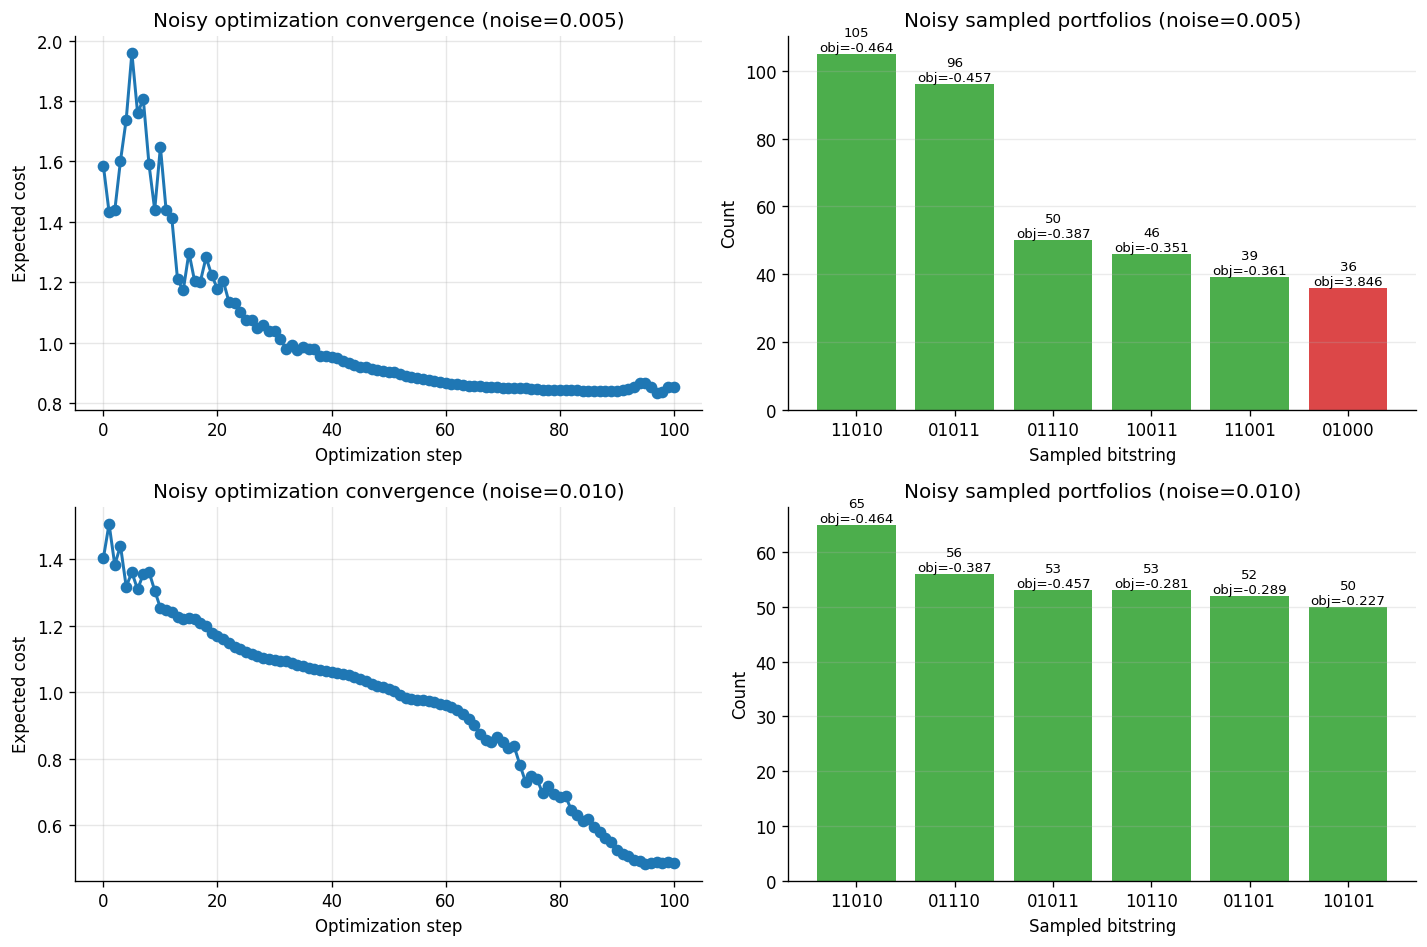

In [56]:
fig, axes = plt.subplots(len(noisy_active_demo_runs), 2, figsize=(12, 4 * len(noisy_active_demo_runs)), squeeze=False)

for row, noisy_run in enumerate(noisy_active_demo_runs):
    noise_strength = noisy_run["noise_strength"]
    noisy_active_demo_result = noisy_run["result"]
    plot_optimization_convergence(noisy_active_demo_result, ax=axes[row, 0])
    axes[row, 0].set_title(f"Noisy optimization convergence (noise={noise_strength:.3f})")
    plot_bitstring_distribution(noisy_active_demo_result, top_k=6, ax=axes[row, 1])
    axes[row, 1].set_title(f"Noisy sampled portfolios (noise={noise_strength:.3f})")

plt.tight_layout()
plt.show()


### 14.1 3-asset noisy depth sweep

This depth study averages each `p` value across three random 3-asset portfolio instances, then plots optimum probability and feasible sample rate with error bars.


3-asset noisy depth sweep
n_assets  B  param_name  param_value  mean_classical_optimum_prob  std_classical_optimum_prob  mean_feasible_sample_rate  std_feasible_sample_rate  mean_final_expected_cost  mean_runtime_sec
--------  -  ----------  -----------  ---------------------------  --------------------------  -------------------------  ------------------------  ------------------------  ----------------
3         2  p           0            0.1133                       0.0152                      0.3678                     0.0283                    0.9024                    0.0044          
3         2  p           1            0.1267                       0.0558                      0.3322                     0.1150                    0.7659                    0.2707          
3         2  p           2            0.2656                       0.0245                      0.7289                     0.0231                    0.1900                    0.4508          
3         2  p     

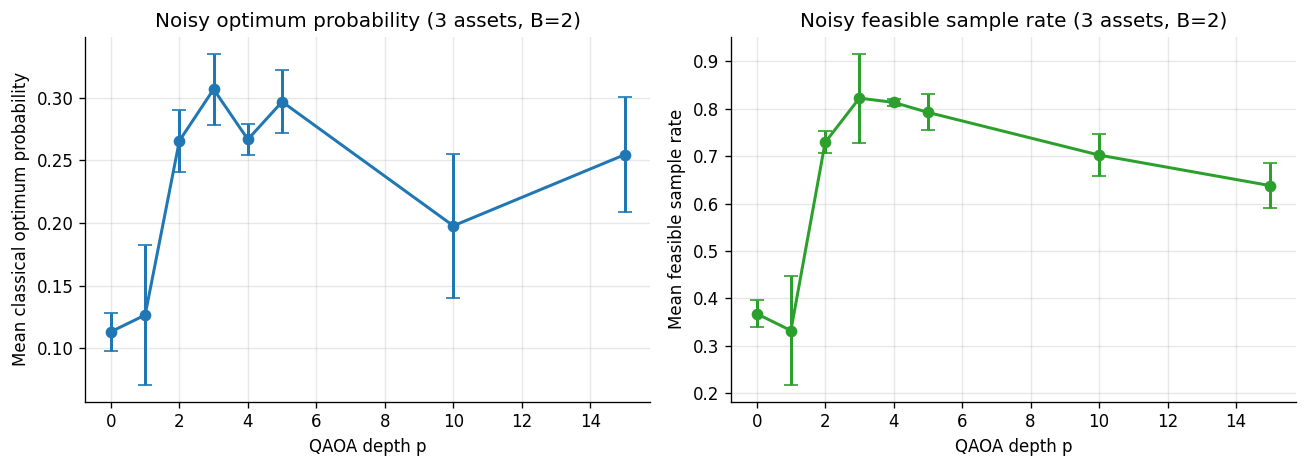

In [57]:
noisy_3asset_depth_config = {
    "n_assets": 3,
    "B": 2,
    "q": noisy_shared_defaults["q"],
    "lam": noisy_shared_defaults["lam"],
    "p": 1,
    "shots": noisy_shared_defaults["shots"],
    "stepsize": noisy_shared_defaults["stepsize"],
    "n_steps": noisy_shared_defaults["n_steps"],
    "optimizer_name": noisy_shared_defaults["optimizer_name"],
    "noise_mode": noisy_shared_defaults["noise_mode"],
    "noise_strength": noisy_shared_defaults["noise_strength"],
}

noisy_depth_sweep_3 = sweep_noisy_hyperparam(
    noisy_3asset_depth_config,
    param_name="p",
    values=noisy_depth_values,
    instance_seeds=noisy_depth_instance_seeds[3],
)

print("3-asset noisy depth sweep")
print_noisy_sweep_summary_table(noisy_depth_sweep_3)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
plot_noisy_optimum_probability(noisy_depth_sweep_3, ax=axes[0])
plot_noisy_feasible_sample_rate(noisy_depth_sweep_3, ax=axes[1])
plt.tight_layout()


### 14.2 4-asset noisy depth sweep

This depth study mirrors the 3-asset case, but averages each `p` value across three random 4-asset portfolio instances.


4-asset noisy depth sweep
n_assets  B  param_name  param_value  mean_classical_optimum_prob  std_classical_optimum_prob  mean_feasible_sample_rate  std_feasible_sample_rate  mean_final_expected_cost  mean_runtime_sec
--------  -  ----------  -----------  ---------------------------  --------------------------  -------------------------  ------------------------  ------------------------  ----------------
4         2  p           0            0.0733                       0.0054                      0.3844                     0.0442                    0.7743                    0.0052          
4         2  p           1            0.1100                       0.0205                      0.6578                     0.0434                    0.2241                    0.4507          
4         2  p           2            0.1456                       0.0314                      0.7000                     0.0303                    0.4213                    0.7246          
4         2  p     

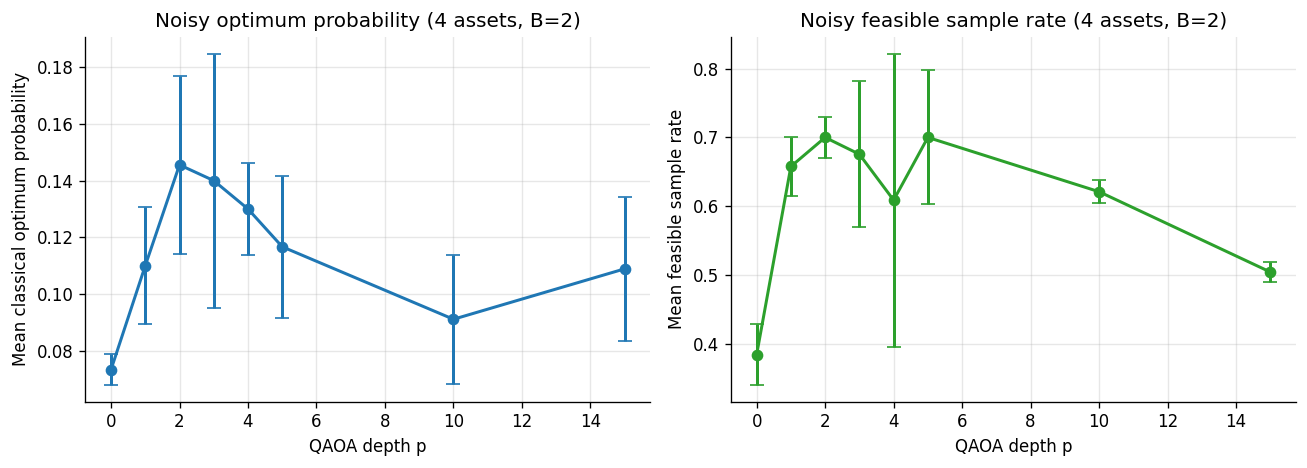

In [58]:
noisy_4asset_depth_config = {
    "n_assets": 4,
    "B": 2,
    "q": noisy_shared_defaults["q"],
    "lam": noisy_shared_defaults["lam"],
    "p": 1,
    "shots": noisy_shared_defaults["shots"],
    "stepsize": noisy_shared_defaults["stepsize"],
    "n_steps": noisy_shared_defaults["n_steps"],
    "optimizer_name": noisy_shared_defaults["optimizer_name"],
    "noise_mode": noisy_shared_defaults["noise_mode"],
    "noise_strength": noisy_shared_defaults["noise_strength"],
}

noisy_depth_sweep_4 = sweep_noisy_hyperparam(
    noisy_4asset_depth_config,
    param_name="p",
    values=noisy_depth_values,
    instance_seeds=noisy_depth_instance_seeds[4],
)

print("4-asset noisy depth sweep")
print_noisy_sweep_summary_table(noisy_depth_sweep_4)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
plot_noisy_optimum_probability(noisy_depth_sweep_4, ax=axes[0])
plot_noisy_feasible_sample_rate(noisy_depth_sweep_4, ax=axes[1])
plt.tight_layout()


### 14.3 Shared noisy sweep configuration

All full-sweep ranges are defined here in one place so the two Cartesian studies below use the same hyperparameter grid structure.


In [7]:
noisy_sweep_space = {
    "p": [0, 1, 3, 5, 10],
    "lam": [1.0, 1.25],
    "shots": [100, 300, 1000],
    "stepsize": [0.05, 0.1, 0.2],
    "n_steps": [50, 100, 200],
}

noisy_instance_seeds = {
    3: noisy_depth_instance_seeds[3],
    4: noisy_depth_instance_seeds[4],
}

noisy_base_configs = {
    3: {
        "n_assets": 3,
        "B": 2,
        "q": noisy_shared_defaults["q"],
        "lam": noisy_shared_defaults["lam"],
        "p": 2,
        "shots": noisy_shared_defaults["shots"],
        "stepsize": noisy_shared_defaults["stepsize"],
        "n_steps": noisy_shared_defaults["n_steps"],
        "optimizer_name": noisy_shared_defaults["optimizer_name"],
        "noise_mode": noisy_shared_defaults["noise_mode"],
        "noise_strength": noisy_shared_defaults["noise_strength"],
    },
    4: {
        "n_assets": 4,
        "B": 2,
        "q": noisy_shared_defaults["q"],
        "lam": noisy_shared_defaults["lam"],
        "p": 2,
        "shots": noisy_shared_defaults["shots"],
        "stepsize": noisy_shared_defaults["stepsize"],
        "n_steps": noisy_shared_defaults["n_steps"],
        "optimizer_name": noisy_shared_defaults["optimizer_name"],
        "noise_mode": noisy_shared_defaults["noise_mode"],
        "noise_strength": noisy_shared_defaults["noise_strength"],
    },
}

RUN_FULL_NOISY_SWEEPS = False

noisy_total_configurations = 1
for values in noisy_sweep_space.values():
    noisy_total_configurations *= len(values)

print("Shared Cartesian sweep space:")
for key, values in noisy_sweep_space.items():
    print(f" - {key}: {values}")
print("Instance seeds:", noisy_instance_seeds)
print("Base configs:")
for n_assets, config in noisy_base_configs.items():
    print(
        f" - n={n_assets}: B={config['B']}, q={config['q']}, lam={config['lam']}, "
        f"shots={config['shots']}, stepsize={config['stepsize']}, n_steps={config['n_steps']}"
    )
print("RUN_FULL_NOISY_SWEEPS =", RUN_FULL_NOISY_SWEEPS)
print("Configurations per asset count =", noisy_total_configurations)


Shared Cartesian sweep space:
 - p: [0, 1, 3, 5, 10]
 - lam: [1.0, 1.25]
 - shots: [100, 300, 1000]
 - stepsize: [0.05, 0.1, 0.2]
 - n_steps: [50, 100, 200]
Instance seeds: {3: [103, 203, 303], 4: [104, 204, 304]}
Base configs:
 - n=3: B=2, q=1.0, lam=1.0, shots=300, stepsize=0.1, n_steps=20
 - n=4: B=2, q=1.0, lam=1.0, shots=300, stepsize=0.1, n_steps=20
RUN_FULL_NOISY_SWEEPS = False
Configurations per asset count = 270


### 14.4 3-asset Cartesian noisy sweep

This optional full-grid study compares every combination in the shared sweep space for the 3-asset case and ranks the results in one sorted table.


In [8]:
if RUN_FULL_NOISY_SWEEPS:
    noisy_cartesian_sweep_3 = run_noisy_cartesian_sweep(
        noisy_base_configs[3],
        noisy_sweep_space,
        instance_seeds=noisy_instance_seeds[3],
    )
    print(
        f"3-asset Cartesian noisy sweep ({noisy_cartesian_sweep_3['n_configurations']} configurations)"
    )
    print_noisy_sweep_summary_table(noisy_cartesian_sweep_3)
    cartesian_csv_3 = save_noisy_sweep_results_csv(
        noisy_cartesian_sweep_3,
        output_dir=noisy_results_dir,
        prefix="noisy_cartesian_3asset",
    )
    print("Saved CSV:", cartesian_csv_3)
else:
    print(
        f"3-asset Cartesian noisy sweep skipped. Set RUN_FULL_NOISY_SWEEPS = True to run "
        f"{noisy_total_configurations} configurations averaged across {len(noisy_instance_seeds[3])} random portfolios."
    )


3-asset Cartesian noisy sweep skipped. Set RUN_FULL_NOISY_SWEEPS = True to run 270 configurations averaged across 3 random portfolios.


### 14.5 4-asset Cartesian noisy sweep

This optional full-grid study applies the same shared sweep space to the 4-asset case and writes the ranked comparison to CSV when run.


In [9]:
if RUN_FULL_NOISY_SWEEPS:
    noisy_cartesian_sweep_4 = run_noisy_cartesian_sweep(
        noisy_base_configs[4],
        noisy_sweep_space,
        instance_seeds=noisy_instance_seeds[4],
    )
    print(
        f"4-asset Cartesian noisy sweep ({noisy_cartesian_sweep_4['n_configurations']} configurations)"
    )
    print_noisy_sweep_summary_table(noisy_cartesian_sweep_4)
    cartesian_csv_4 = save_noisy_sweep_results_csv(
        noisy_cartesian_sweep_4,
        output_dir=noisy_results_dir,
        prefix="noisy_cartesian_4asset",
    )
    print("Saved CSV:", cartesian_csv_4)
else:
    print(
        f"4-asset Cartesian noisy sweep skipped. Set RUN_FULL_NOISY_SWEEPS = True to run "
        f"{noisy_total_configurations} configurations averaged across {len(noisy_instance_seeds[4])} random portfolios."
    )


4-asset Cartesian noisy sweep skipped. Set RUN_FULL_NOISY_SWEEPS = True to run 270 configurations averaged across 3 random portfolios.


## 15. Post-process saved Cartesian results

These utilities read two saved Cartesian-search CSV files directly and generate one inline figure per hyperparameter without rerunning any QAOA experiments. Each figure shows the **score-weighted distribution on the left** and the **top-k frequency distribution on the right**.


Displaying post-processed hyperparameter figure for p.


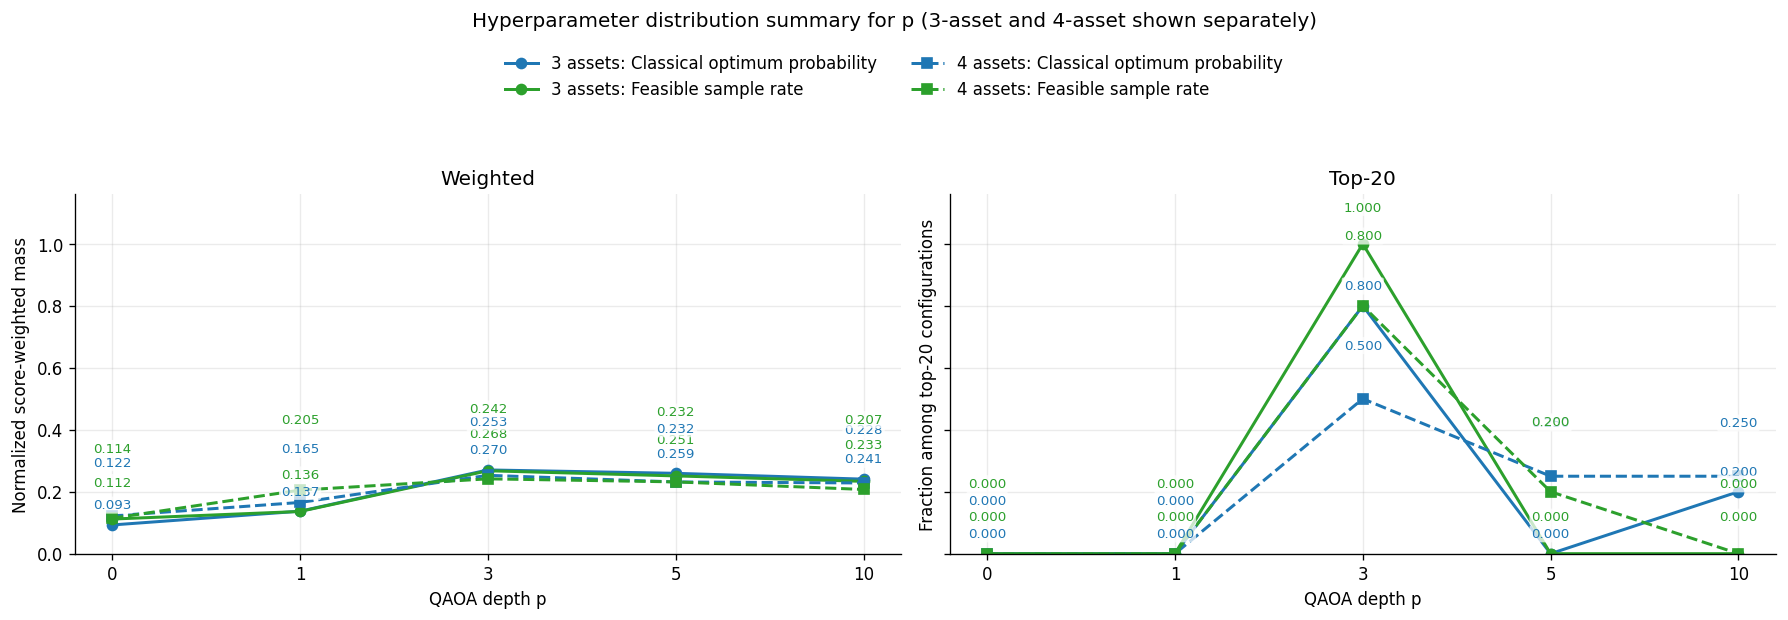

Displaying post-processed hyperparameter figure for lam.


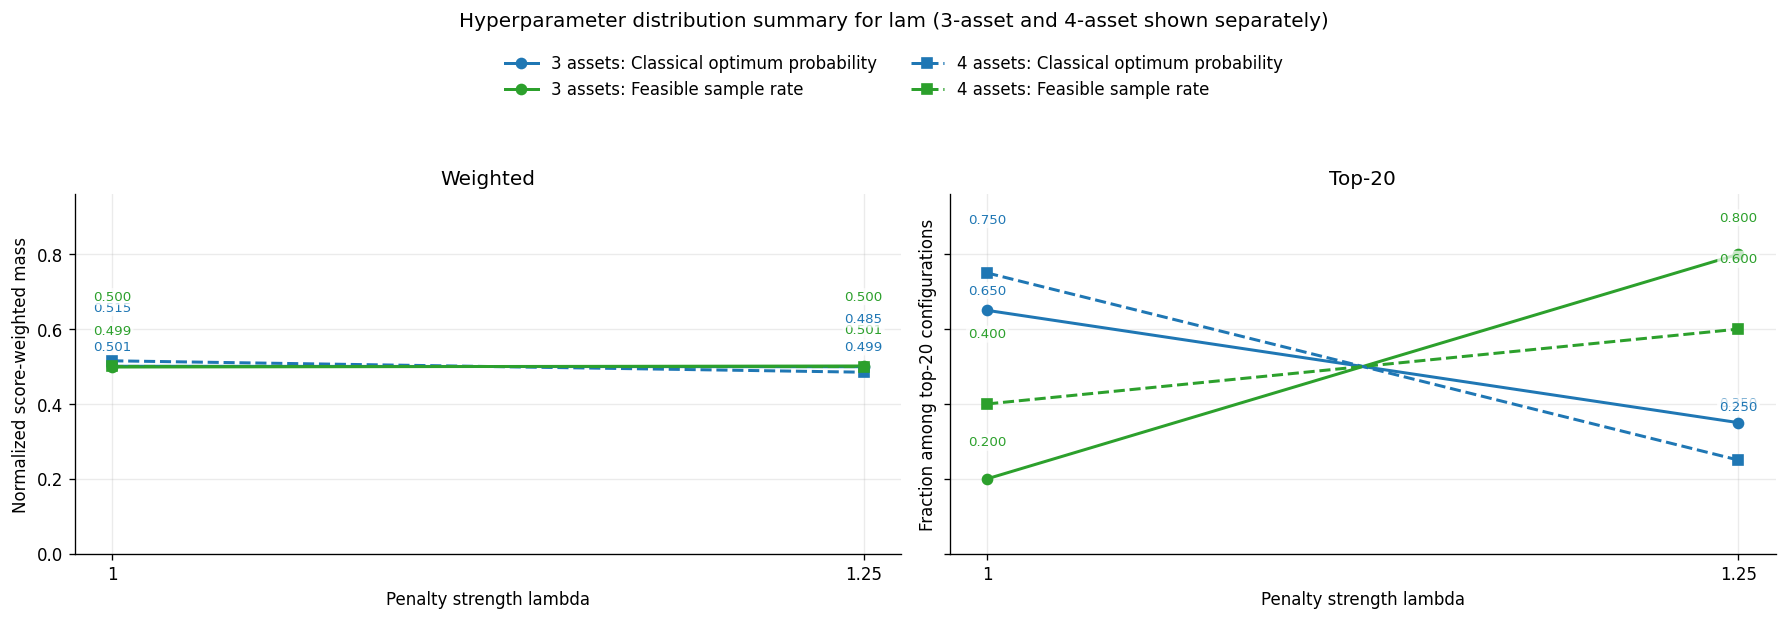

Displaying post-processed hyperparameter figure for shots.


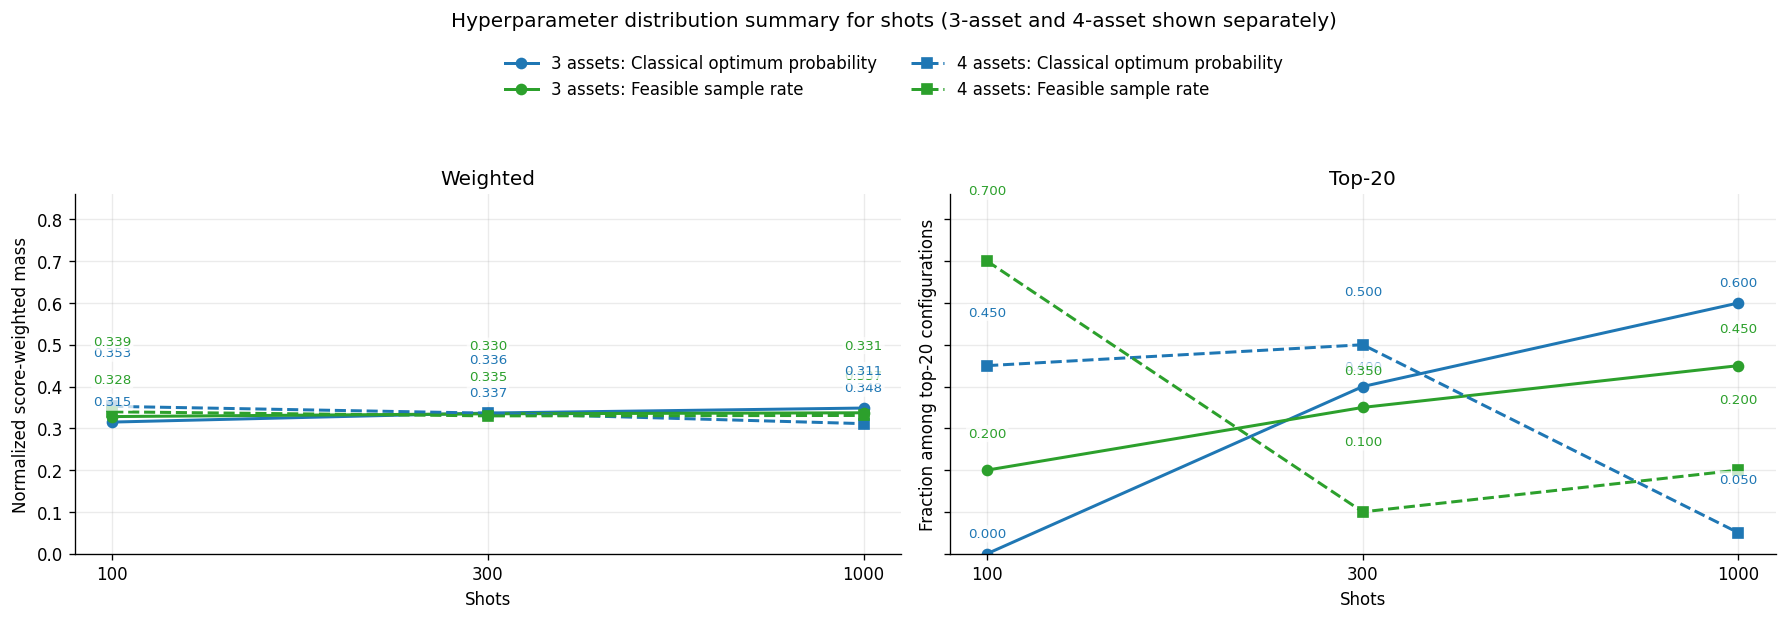

Displaying post-processed hyperparameter figure for stepsize.


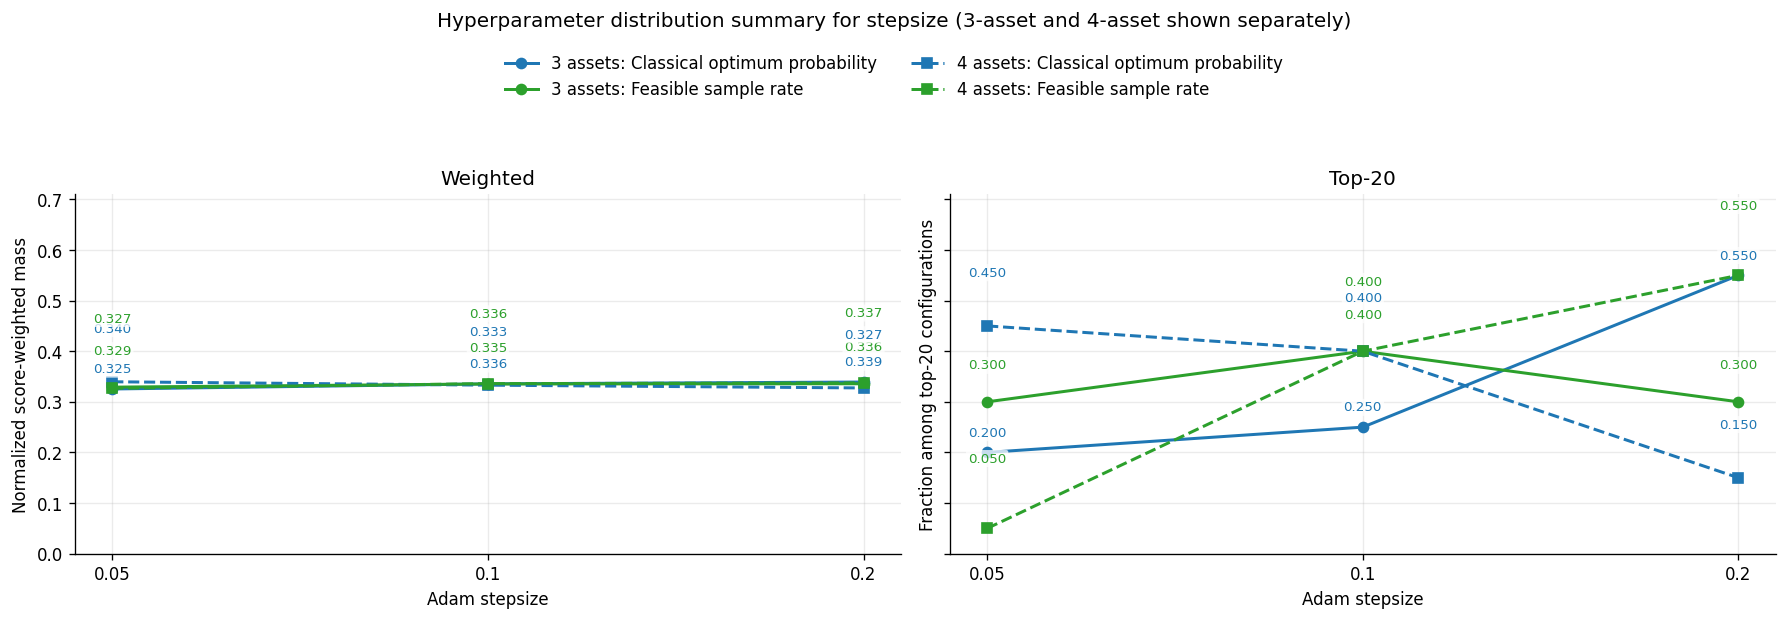

Displaying post-processed hyperparameter figure for n_steps.


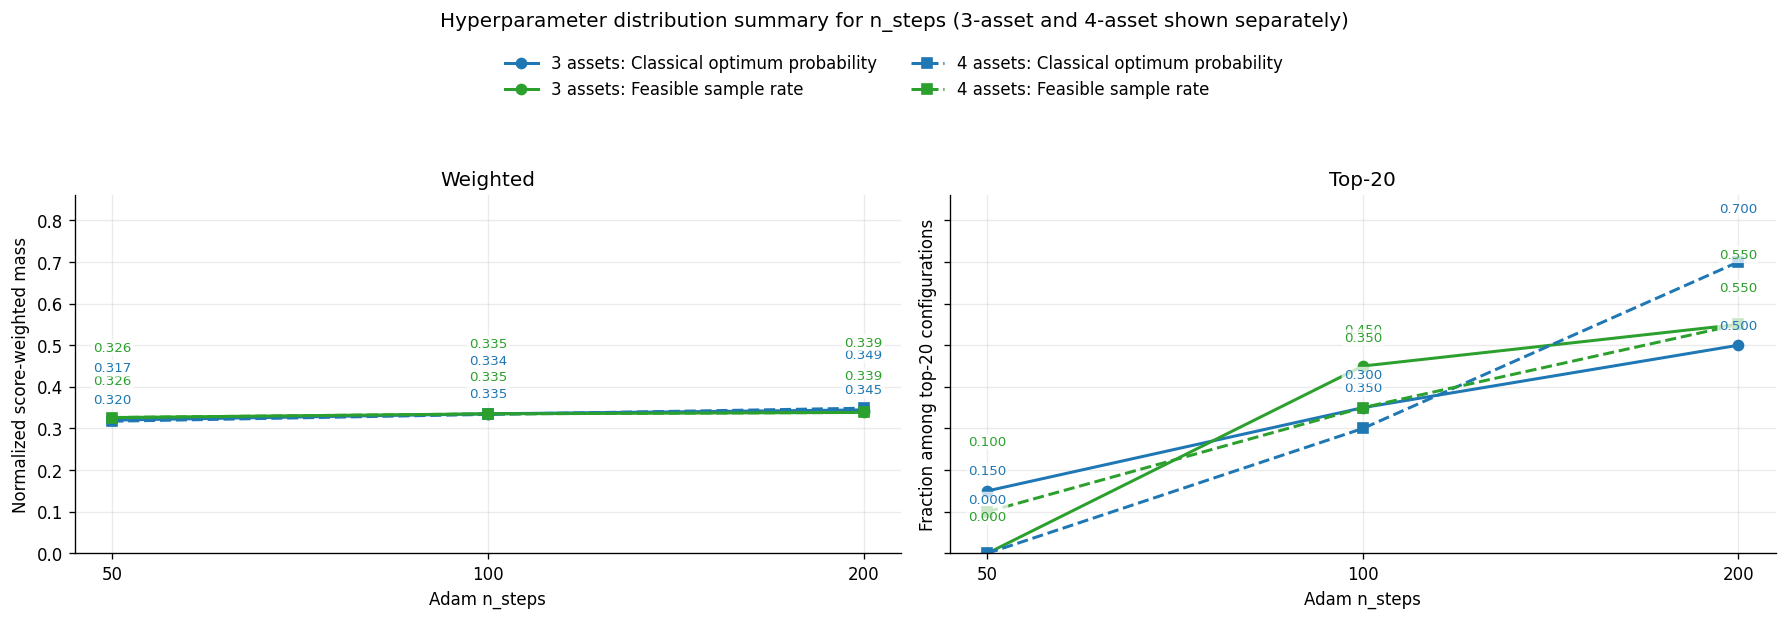

Displayed weighted-left / top-k-right hyperparameter plots in the notebook.
Saved post-processing figures to: C:\Users\anton\Documents\VSCODE PROJECTS\QAOA\pennylane\noisy_results\postprocessed_results
Top-k summary tables available for: ['p', 'lam', 'shots', 'stepsize', 'n_steps']
Weighted summary tables available for: ['p', 'lam', 'shots', 'stepsize', 'n_steps']


In [ ]:
from IPython.display import display
import importlib
import portfolio_qaoa_core as _portfolio_qaoa_core

_portfolio_qaoa_core = importlib.reload(_portfolio_qaoa_core)
postprocess_saved_search_results = _portfolio_qaoa_core.postprocess_saved_search_results

postprocess_csv_1 = noisy_results_dir / "noisy_cartesian_3asset_20260408_174613.csv"  # or set to another saved 3-asset Cartesian CSV
postprocess_csv_2 = noisy_results_dir / "noisy_cartesian_4asset_20260408_192944.csv"  # or set to another saved 4-asset Cartesian CSV
postprocess_top_k = 20
postprocess_output_dir = None # noisy_results_dir / "postprocessed_results"  # set to a path only if you also want image files saved
RUN_POSTPROCESS_SAVED_RESULTS = True

if RUN_POSTPROCESS_SAVED_RESULTS:
    if postprocess_csv_1 is None or postprocess_csv_2 is None:
        raise ValueError(
            "Set postprocess_csv_1 and postprocess_csv_2 to two saved Cartesian result CSV files."
        )

    postprocess_results = postprocess_saved_search_results(
        postprocess_csv_1,
        postprocess_csv_2,
        top_k=postprocess_top_k,
        output_dir=postprocess_output_dir,
    )

    for hyperparam, figure in postprocess_results["figures"].items():
        print(f"Displaying post-processed hyperparameter figure for {hyperparam}.")
        display(figure)
        plt.close(figure)

    print("Displayed weighted-left / top-k-right hyperparameter plots in the notebook.")
    if postprocess_results["output_dir"] is not None:
        print("Saved post-processing figures to:", postprocess_results["output_dir"])
    print("Top-k summary tables available for:", list(postprocess_results["topk"]["summary_tables"].keys()))
    print("Weighted summary tables available for:", list(postprocess_results["weighted"]["summary_tables"].keys()))
else:
    print(
        "Set RUN_POSTPROCESS_SAVED_RESULTS = True and point postprocess_csv_1 / postprocess_csv_2 "
        "at two saved Cartesian CSVs to display the post-processing figures in the notebook."
    )
